# Настройка окружения


In [1]:
using_colab = True

In [ ]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam2.git'

    !mkdir -p images
    !wget -P images https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/truck.jpg
    !wget -P images https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/groceries.jpg

    !mkdir -p ../checkpoints/
    !wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt

In [3]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


In [5]:
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(4, 4))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

In [6]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

predictor = SAM2ImagePredictor(sam2_model)

# Создание масок

Для создания масок использовалась модель SAM, промптами для которой были bounding boxes, полученные с помощью MTCNN.

In [17]:
from google.colab import drive
drive.mount('/content/drive')
dir_path = '/content/drive/MyDrive/Курсовой_проект'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


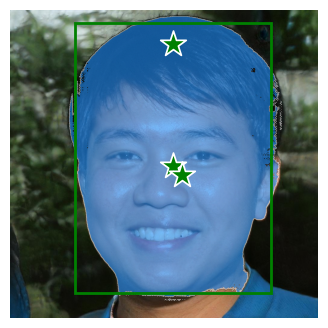

In [18]:
image = Image.open('/content/drive/MyDrive/Курсовой_проект/photo_original.jpeg')
predictor.set_image(image)
with open('/content/drive/MyDrive/Курсовой_проект/box_photo_original.txt') as f:
    input_box = list(map(float, f.read().split(',')))
c_x = (input_box[0] + input_box[2]) / 2
c_y = (input_box[1] + input_box[3]) / 2
input_point = np.array([[c_x, c_y], [c_x, input_box[1]+1], [c_x+30, c_y+30]])
input_label = np.array([1, 1, 1])
input_box[1] -= 70
input_box[3] += 20
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False,
)
show_masks(image, masks, scores, box_coords=input_box, point_coords=input_point, input_labels=input_label)

In [21]:
Image.fromarray((masks[0] * 255).astype(np.uint8)).save(f'{dir_path}/mask_photo_original.jpeg')

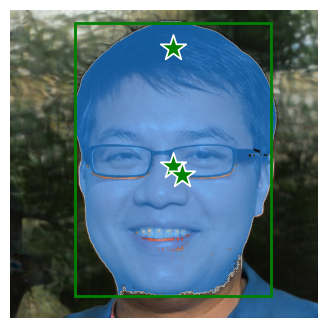

In [22]:
image = Image.open('/content/drive/MyDrive/Курсовой_проект/photo_older.jpeg')
predictor.set_image(image)
with open('/content/drive/MyDrive/Курсовой_проект/box_photo_original.txt') as f:
    input_box = list(map(float, f.read().split(',')))
c_x = (input_box[0] + input_box[2]) / 2
c_y = (input_box[1] + input_box[3]) / 2
input_point = np.array([[c_x, c_y], [c_x, input_box[1]+15], [c_x+30, c_y+30]])
input_label = np.array([1, 1, 1])
input_box[1] -= 70
input_box[3] += 30
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False,
)
show_masks(image, masks, scores, box_coords=input_box, point_coords=input_point, input_labels=input_label)

In [23]:
Image.fromarray((masks[0] * 255).astype(np.uint8)).save(f'{dir_path}/mask_photo_older.jpeg')

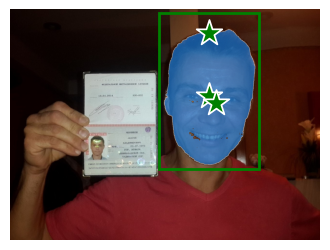

In [25]:
image = Image.open('/content/drive/MyDrive/Курсовой_проект/selfie.jpeg')
predictor.set_image(image)
with open('/content/drive/MyDrive/Курсовой_проект/box_selfie.txt') as f:
    input_box = list(map(float, f.read().split(',')))
c_x = (input_box[0] + input_box[2]) / 2
c_y = (input_box[1] + input_box[3]) / 2
input_point = np.array([[c_x, c_y], [c_x, input_box[1]+15], [c_x+30, c_y+30]])
input_label = np.array([1, 1, 1])
input_box[1] -= 70
input_box[3] += 30
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False,
)
show_masks(image, masks, scores, box_coords=input_box, point_coords=input_point, input_labels=input_label)

In [26]:
Image.fromarray((masks[0] * 255).astype(np.uint8)).save(f'{dir_path}/mask_selfie_face.jpeg')

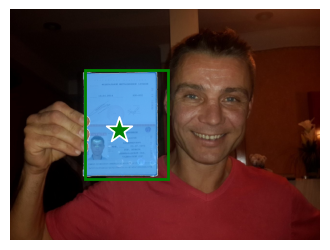

In [28]:
input_box = np.array([310, 250, 650, 700])
input_point = np.array([[450, 500]])
input_label = np.array([1])
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False,
)
show_masks(image, masks, scores, box_coords=input_box, point_coords=input_point, input_labels=input_label)

In [29]:
Image.fromarray((masks[0] * 255).astype(np.uint8)).save(f'{dir_path}/mask_selfie_doc.jpeg')

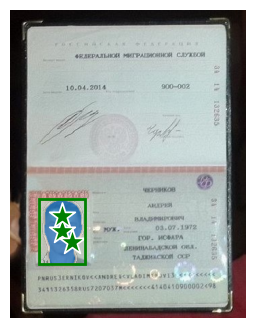

In [31]:
image = Image.open('/content/drive/MyDrive/Курсовой_проект/document.jpeg')
predictor.set_image(image)
with open('/content/drive/MyDrive/Курсовой_проект/box_document.txt') as f:
    input_box = list(map(float, f.read().split(',')))
c_x = (input_box[0] + input_box[2]) / 2
c_y = (input_box[1] + input_box[3]) / 2
input_point = np.array([[c_x, c_y], [c_x, input_box[1]+15], [c_x+15, c_y+15]])
input_label = np.array([1, 1, 1])
input_box[1] -= 10
input_box[3] += 10
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False,
)
show_masks(image, masks, scores, box_coords=input_box, point_coords=input_point, input_labels=input_label)

In [32]:
Image.fromarray((masks[0] * 255).astype(np.uint8)).save(f'{dir_path}/mask_doc_photo.jpeg')

In [ ]:
# https://drive.google.com/uc?export=view&id=1EM75L2OTNO4X4lqweN3tedc1do6q7tu8 - селфи
# https://drive.google.com/uc?export=view&id=1NT0lkRws5Q0m1az8xISq45i6kEhckZ1k - маска лицо селфи
# https://drive.google.com/uc?export=view&id=1MuDYJJwBzOAeG9I-8fTrKQMFHnu5TMae - сген. фото, старый
# https://drive.google.com/uc?export=view&id=19Ube3jQhHTu0nG-n5QEHnmoIJfGM8BcD - маска сген. фото старый


# Встраивание фото в шаблон

В качестве модели, соединяющей результаты на одном изображении, была испольована модель insert-anything, использующая маски объектов для определения участка изображения, необходимые для добавления в другую область.
Для взаимодействия с моделью использовался API ComfyUI.

In [117]:
import base64
# сохраняем изображения в нужном формате
with open("/content/drive/MyDrive/Курсовой_проект/photo_older.jpeg", "rb") as f:
    image_data = base64.b64encode(f.read()).decode('utf-8')
    photo_older_url = f"data:image/jpeg;base64,{image_data}"

with open("/content/drive/MyDrive/Курсовой_проект/mask_photo_older.jpeg", "rb") as f:
    image_data = base64.b64encode(f.read()).decode('utf-8')
    mask_photo_older_url = f"data:image/jpeg;base64,{image_data}"

with open("/content/drive/MyDrive/Курсовой_проект/selfie.jpeg", "rb") as f:
    image_data = base64.b64encode(f.read()).decode('utf-8')
    selfie_url = f"data:image/jpeg;base64,{image_data}"

with open("/content/drive/MyDrive/Курсовой_проект/mask_selfie_face.jpeg", "rb") as f:
    image_data = base64.b64encode(f.read()).decode('utf-8')
    mask_selfie_face_url = f"data:image/jpeg;base64,{image_data}"

with open("/content/drive/MyDrive/Курсовой_проект/mask_photo_original.jpeg", "rb") as f:
    image_data = base64.b64encode(f.read()).decode('utf-8')
    mask_photo_original_url = f"data:image/jpeg;base64,{image_data}"

with open("/content/drive/MyDrive/Курсовой_проект/photo_original.jpeg", "rb") as f:
    image_data = base64.b64encode(f.read()).decode('utf-8')
    photo_original_url = f"data:image/jpeg;base64,{image_data}"

with open("/content/drive/MyDrive/Курсовой_проект/mask_selfie_photo.jpeg", "rb") as f:
    image_data = base64.b64encode(f.read()).decode('utf-8')
    mask_selfie_photo_url = f"data:image/jpeg;base64,{image_data}"


In [105]:
import requests
import time

# Ваши данные
deployment_id = "2db65be5-8490-4e1a-a07e-346b92d720d6"
token = "17894a70-b9c4-44ab-9841-d77340e06c80"

# создание изображения в 2 этапа:
# 1. добавить в шаблон(таргет) лицо на селфи
# 2. добавить в шаблон(таргет) лицо на паспорт
'''
узлы:
 108: изображение-таргет
 109: маска-источник
 110: изображение-источник
 111: маска-таргет
'''
node_108 = [selfie_url, selfie_url]
node_109 = [mask_photo_older_url, mask_photo_original_url]
node_110 = [photo_older_url, photo_original_url]
node_111 = [mask_selfie_face_url, mask_selfie_photo_url]
for step in range(2):
    if step == 1:
        with open(f"/content/drive/MyDrive/Курсовой_проект/image_step_{step-1}.jpeg", "rb") as f:
            image_data = base64.b64encode(f.read()).decode('utf-8')
            node_108[1] = f"data:image/jpeg;base64,{image_data}"
    # Формируем запрос
    payload = {
        "overrides": {
            "110": {  # ID узла с изображением
                "inputs": {
                    "image": node_110[step]
                }
            },
            "109": {  # ID узла с маской
                "inputs": {
                    "image": node_109[step]
                }
            },
            "108": {  # ID узла с изображением
                "inputs": {
                    "image": node_108[step]
                }
            },
            "111": {  # ID узла с маской
                "inputs": {
                    "image": node_111[step]
                }
            },
            "98": {  # ID узла с текстовым промптом
                "inputs": {
                    "prompt": "white circle"
                }
            },
            "99": {  # ID узла с текстовым промптом
                "inputs": {
                    "prompt": "white circle"
                }
            },
        }
    }

    # Отправляем запрос
    response = requests.post(
        f"https://api.runcomfy.net/prod/v1/deployments/{deployment_id}/inference",
        headers={
            "Content-Type": "application/json",
            "Authorization": f"Bearer {token}"
        },
        json=payload
    )

    print(response.json())
    result = response.json()
    status_url = result.get('status_url')
    result_url = result.get('result_url')

    # ждем ответа
    max_attempts = 100  # Максимальное количество попыток
    attempt = 0
    status = "in_queue"
    while status not in ["completed", "succeeded", "failed"] and attempt < max_attempts:
        time.sleep(10)
        attempt += 1

        status_response = requests.get(
            status_url,
            headers={"Authorization": f"Bearer {token}"}
        )
        status_data = status_response.json()
        status = status_data.get('status')

    # получаем ответ после завершения
    result_response = requests.get(
        result_url,
        headers={"Authorization": f"Bearer {token}"}
    )

    if result_response.status_code != 200:
        print(f"❌ Ошибка при получении результата: {result_response.status_code}")
        print(result_response.text)
        exit()

    result_data = result_response.json()
    print(f"✅ Результат шага {step} получен!")
    print(f"📊 Данные результата: {result_data}")

    # Скачиваем все финальные изображения
    for node_id, node_data in result_data['outputs'].items():
        if node_id == '102' and node_data['images'][0]['type'] == 'output':
            image_url = node_data['images'][0]['url']
            filename = f'/content/drive/MyDrive/Курсовой_проект/image_step_{step}.jpeg'

            print(f"📥 Скачиваем {filename}...")
            response = requests.get(image_url)

            if response.status_code == 200:
                # Сохраняем файл
                with open(filename, 'wb') as f:
                    f.write(response.content)
                print(f"✅ Сохранено: {filename}")

                # Показываем изображение (для Jupyter/Colab)
                try:
                    from IPython.display import Image as IPImage, display
                    print(f"🖼️ Превью {filename}:")
                    display(IPImage(filename))
                    break
                except:
                    pass
            else:
                print(f"❌ Ошибка при скачивании {filename}")

{'request_id': 'dd9641f4-e58e-47db-96e6-4684f2068145', 'status_url': 'https://api.runcomfy.net/prod/v1/deployments/2db65be5-8490-4e1a-a07e-346b92d720d6/requests/dd9641f4-e58e-47db-96e6-4684f2068145/status', 'result_url': 'https://api.runcomfy.net/prod/v1/deployments/2db65be5-8490-4e1a-a07e-346b92d720d6/requests/dd9641f4-e58e-47db-96e6-4684f2068145/result', 'cancel_url': 'https://api.runcomfy.net/prod/v1/deployments/2db65be5-8490-4e1a-a07e-346b92d720d6/requests/dd9641f4-e58e-47db-96e6-4684f2068145/cancel'}


📥 Скачиваем 1226_00003_.png...
✅ Сохранено: 1226_00003_.png
🖼️ Превью 1226_00003_.png:


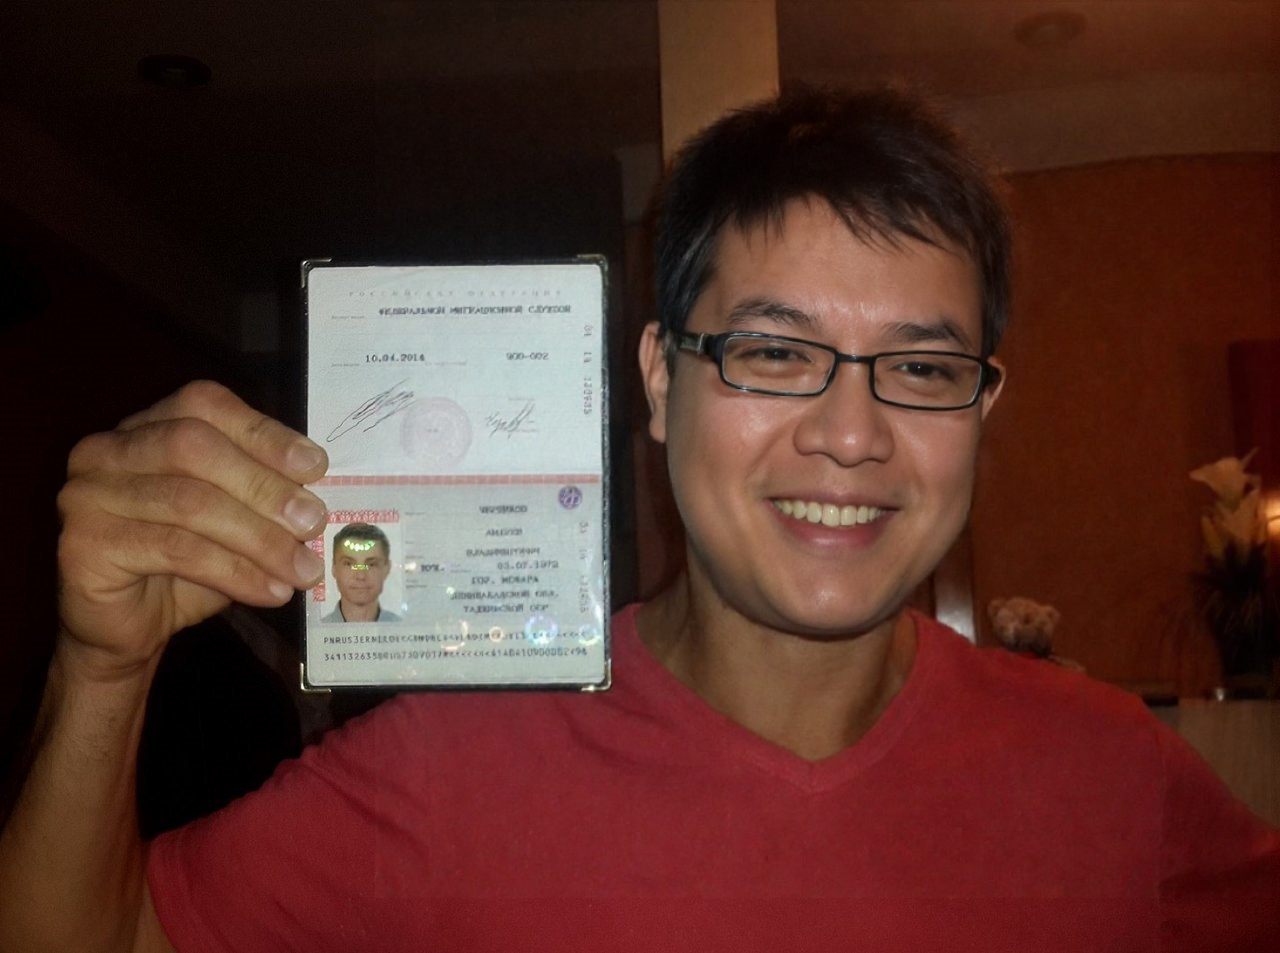

In [115]:
import requests
from PIL import Image
from io import BytesIO

# Скачиваем все финальные изображения
for node_id, node_data in result_data['outputs'].items():
    if node_id == '102' and node_data['images'][0]['type'] == 'output':
        image_url = node_data['images'][0]['url']
        filename = node_data['images'][0]['filename']

        print(f"📥 Скачиваем {filename}...")
        response = requests.get(image_url)

        if response.status_code == 200:
            # Сохраняем файл
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f"✅ Сохранено: {filename}")

            # Показываем изображение (для Jupyter/Colab)
            try:
                from IPython.display import Image as IPImage, display
                print(f"🖼️ Превью {filename}:")
                display(IPImage(filename))
            except:
                pass
        else:
            print(f"❌ Ошибка при скачивании {filename}")